HỒI QUY TUYẾN TÍNH

Linear Regression

HỒI QUY TUYẾN TÍNH ĐƠN BIẾN

Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot

In [2]:
path01 = os.getcwd() + '/data/ex1data1.txt'

In [3]:
path02 = os.getcwd() + '/data/ex1data2.txt'

In [4]:
tenCot = ['Population', 'Profit']
duLieu = pd.read_csv(path01, names=tenCot)
print(duLieu.head())

   Population   Profit
0      6.1101  17.5920
1      5.5277   9.1302
2      8.5186  13.6620
3      7.0032  11.8540
4      5.8598   6.8233


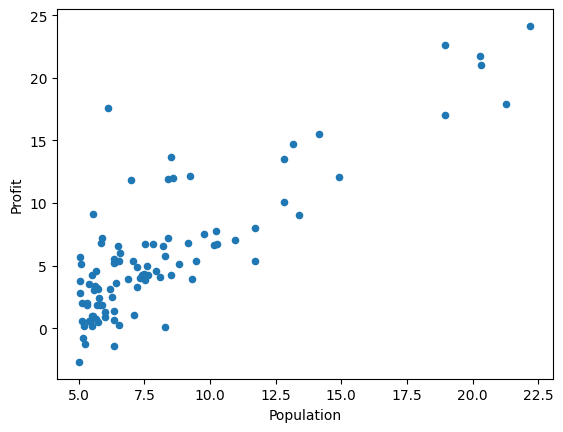

In [5]:
duLieu.plot(kind='scatter', x='Population', y='Profit')
pyplot.show()

Mô hình hồi quy tuyến tính đơn biến

In [11]:
maTran=duLieu.values
m,n = maTran.shape
X_tam = maTran[:,0:n-1]
#print(X_tam[:5])
X = np.insert(X_tam, 0, values=1, axis=1)
#axis = 1 là hàng, =0 là cột
#0 là vị trí 0
Y=maTran[:, n-1:n]

print("m =", m, "va", "n=", n)

m = 97 va n= 2


In [13]:
print("In ra 5 hàng đầu tiên")
print('\n')
print(X[:5])
print('\n')
print(Y[:5])

In ra 5 hàng đầu tiên


[[1.     6.1101]
 [1.     5.5277]
 [1.     8.5186]
 [1.     7.0032]
 [1.     5.8598]]


[[17.592 ]
 [ 9.1302]
 [13.662 ]
 [11.854 ]
 [ 6.8233]]


In [14]:
def h_X (X, theta):
  return np.dot(X, theta.T)
  #theta.T là ma trận chuyển vị của theta

In [15]:
theta = np.zeros((1, X.shape[1])) #Khởi tạo vectow theta
print(theta)                      #in ra theta

[[0. 0.]]


In [16]:
print(theta.T)                    #in ra ma trận chuyển vị của theta

[[0.]
 [0.]]


In [17]:
print(X.shape)

(97, 2)


In [18]:
print(Y.shape)

(97, 1)


In [19]:
print(theta.shape)

(1, 2)


Settings hàm chi phí

In [20]:
def computeCost(X, Y, theta):
  SaiSo= np.power((h_X(X, theta)- Y), 2)
  J = (1.0/(2 * m)) * np.sum(SaiSo)
  return J

print(computeCost(X,Y,theta))

32.072733877455676


Thuật toán Gradient descent

In [21]:
def gradientDescent(X, Y, theta, anpha, soLanLap):               #01
  theta_tam= np.zeros(theta.shape)                               #02
  heso_Theta = theta.shape[1]                                    #03
  J_tam = np.zeros(soLanLap)                                     #04
  for i in range(soLanLap):                                      #05
    SaiSo = h_X(X,theta) - Y                                     #06
    for j in range(heso_Theta):                                  #07
      X_ij = np.reshape(X[:, j],(len(X),1))                      #08
      term = np.multiply(SaiSo, X_ij)                            #09
      theta_tam[0,j]=theta[0,j]-((anpha/len(X)) * np.sum(term))  #10
    theta= theta_tam                                           #11
    J_tam[i] = computeCost(X,Y,theta)                          #12
  return theta, J_tam                                          #13

In [22]:
anpha = 0.01
soLanLap = 1000
theta_sauCung, J_chiphi = gradientDescent(X, Y, theta, anpha, soLanLap)
print(theta_sauCung)

[[-3.24140214  1.1272942 ]]


In [23]:
print(J_chiphi[-1])

4.515955503078914


In [24]:
duDoan_profit = ([[1., 40.1], [1., 23.2]]* theta_sauCung)
print(duDoan_profit.sum(axis = 1))

[41.96309537 22.91182335]


Đồ thị hóa mô hình dự đoán

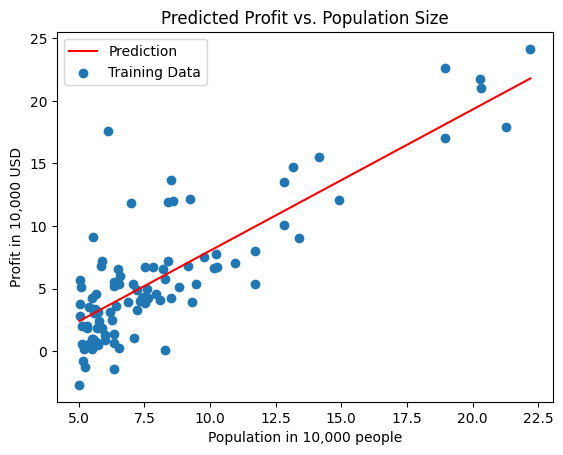

In [25]:
def duDoan_fig():                                          #
    x_pop = np.linspace(X_tam.min(), X_tam.max(), 100)
#Tạo mảng ndarray có 100 ptử đều nhau có giá trị trg [min,max] for cột dữ liệu lưu trữ dân số Citis
    f = theta_sauCung[0, 0] + (theta_sauCung[0, 1] * x_pop)#
    fig, ax = pyplot.subplots()                            #
    ax.plot(x_pop, f, 'r', label='Prediction')             #
    ax.scatter(X_tam, Y, label='Training Data')            #
    ax.legend(loc=2)                                       #
    ax.set_xlabel('Population in 10,000 people')           #đặt tiêu đề trục hoành
    ax.set_ylabel('Profit in 10,000 USD')                  #đặt tiêu đề trục tung
    ax.set_title('Predicted Profit vs. Population Size')   # đặt tiêu đề đồ thị
    pyplot.show()                                          #

duDoan_fig()                                               # hiện đồ thị

Hàm chi phí sau số các bước lặp

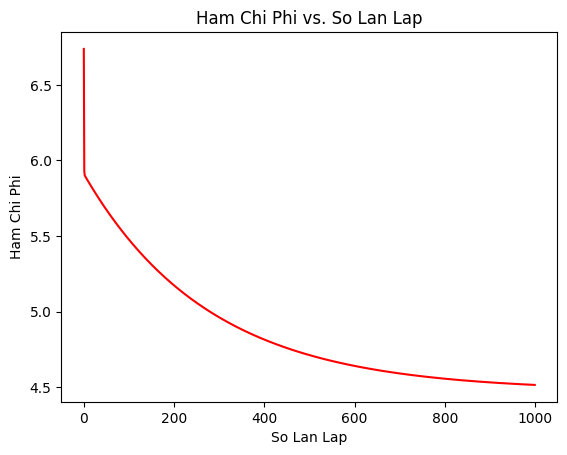

In [26]:
def chiPhi_fig():
  fig, ax = pyplot.subplots()
  ax.plot(np.arange(soLanLap), J_chiphi, 'r')
  ax.set_xlabel('So Lan Lap')
  ax.set_ylabel('Ham Chi Phi')
  ax.set_title('Ham Chi Phi vs. So Lan Lap')
  pyplot.show()

chiPhi_fig()

Bài toán và Data

In [29]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot

In [30]:
#duongdan = os.getcwd() + '\data\ex1data2.txt'
tenCot = ['Size', 'Bedrooms', 'Price']
duLieu = pd.read_csv(path02, names=tenCot)

print(duLieu.shape)

(47, 3)


In [31]:
print(duLieu.head())

   Size  Bedrooms   Price
0  2104         3  399900
1  1600         3  329900
2  2400         3  369000
3  1416         2  232000
4  3000         4  539900


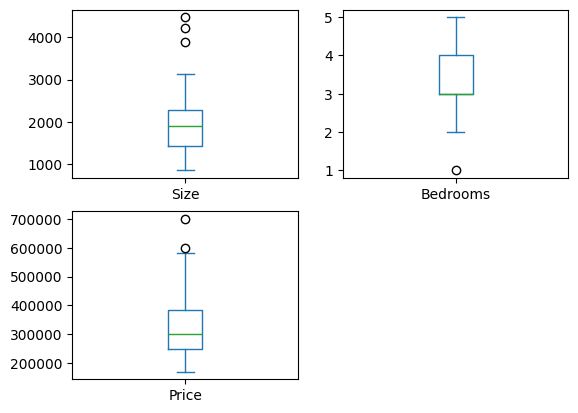

In [32]:
duLieu.plot(kind= 'box', subplots= True, layout= (2,2), sharex= False, sharey= False)
pyplot.show()

Thuật toán Gradient descent

In [39]:
maTran = duLieu.values
m, n = maTran.shape
X_cacCot = maTran[:, 0:n - 1]
X = np.insert(X_cacCot, 0, values = 1, axis = 1)
Y = maTran[:, n - 1: n]
print( X[:5])
print("\n")
print( Y[:5])
print("\n")
print("\n")

theta = np.zeros((1, X.shape[1]))
print(theta)
print("\n")
print(X.shape, Y.shape, theta.shape)
print("\n")
print("\n")

def h_X(X, theta):
  return np.dot(X, theta.T)

def computeCost(X, Y, theta):
  saiSo = np.power((h_X(X, theta) - Y), 2)
  J = (1.0/(2 * m)) * np.sum(saiSo)
  return J

print(computeCost(X, Y, theta))
print("\n")
print("\n")

def gradientDescent(X, Y, theta, alpha, soLanLap):
  theta_tam = np.zeros(theta.shape)
  heso_Theta = theta.shape[1]
  J_tam = np.zeros(soLanLap)
  for i in range(soLanLap):
    saiSo = h_X(X, theta) - Y
    for j in range(heso_Theta):
      X_ij = np.reshape(X[:, j], (len(X), 1))
      term = np.multiply(saiSo, X_ij)
      theta_tam[0, j] = theta[0, j] - ((alpha/ len(X)) * np.sum(term))
    theta = theta_tam
    J_tam[i] = computeCost(X, Y, theta)
  return theta, J_tam

alpha = 0.01
soLanLap = 10
theta_sauCung, J_chiphi = gradientDescent(X, Y, theta, alpha, soLanLap)
print(theta_sauCung)
print("\n")
print(J_chiphi[-1])

[[ 1.          0.13000987 -0.22367519]
 [ 1.         -0.50418984 -0.22367519]
 [ 1.          0.50247636 -0.22367519]
 [ 1.         -0.73572306 -1.53776691]
 [ 1.          1.25747602  1.09041654]]


[[ 0.47574687]
 [-0.08407444]
 [ 0.22862575]
 [-0.86702453]
 [ 1.59538948]]




[[0. 0. 0.]]


(47, 3) (47, 1) (1, 3)




0.4893617021276596




[[1.88974132e-19 7.91040367e-02 3.94834595e-02]]


0.4116140420916037


In [37]:
duLieu = (duLieu - duLieu.mean())/duLieu.std()

maTran = duLieu.values
m, n = maTran.shape
X_cacCot = maTran[:, 0:n - 1]
X = np.insert(X_cacCot, 0, values = 1, axis = 1)
Y = maTran[:, n - 1: n]
print( X[:5])
print("\n")
print( Y[:5])
print("\n")
print("\n")

theta = np.zeros((1, X.shape[1]))
print(theta)
print("\n")
print(X.shape, Y.shape, theta.shape)
print("\n")
print("\n")

def h_X(X, theta):
  return np.dot(X, theta.T)

def computeCost(X, Y, theta):
  saiSo = np.power((h_X(X, theta) - Y), 2)
  J = (1.0/(2 * m)) * np.sum(saiSo)
  return J

print(computeCost(X, Y, theta))
print("\n")
print("\n")

def gradientDescent(X, Y, theta, alpha, soLanLap):
  theta_tam = np.zeros(theta.shape)
  heso_Theta = theta.shape[1]
  J_tam = np.zeros(soLanLap)
  for i in range(soLanLap):
    saiSo = h_X(X, theta) - Y
    for j in range(heso_Theta):
      X_ij = np.reshape(X[:, j], (len(X), 1))
      term = np.multiply(saiSo, X_ij)
      theta_tam[0, j] = theta[0, j] - ((alpha/ len(X)) * np.sum(term))
    theta = theta_tam
    J_tam[i] = computeCost(X, Y, theta)
  return theta, J_tam

alpha = 0.01
soLanLap = 1000
theta_sauCung, J_chiphi = gradientDescent(X, Y, theta, alpha, soLanLap)
print(theta_sauCung)
print("\n")
print(J_chiphi[-1])

[[ 1.          0.13000987 -0.22367519]
 [ 1.         -0.50418984 -0.22367519]
 [ 1.          0.50247636 -0.22367519]
 [ 1.         -0.73572306 -1.53776691]
 [ 1.          1.25747602  1.09041654]]


[[ 0.47574687]
 [-0.08407444]
 [ 0.22862575]
 [-0.86702453]
 [ 1.59538948]]




[[0. 0. 0.]]


(47, 3) (47, 1) (1, 3)




0.4893617021276596




[[-1.53541482e-17  8.78503652e-01 -4.69166570e-02]]


0.13070336960771894


In [38]:
duLieu = (duLieu - duLieu.mean())/duLieu.std()

maTran = duLieu.values
m, n = maTran.shape
X_cacCot = maTran[:, 0:n - 1]
X = np.insert(X_cacCot, 0, values = 1, axis = 1)
Y = maTran[:, n - 1: n]
print( X[:5])
print("\n")
print( Y[:5])
print("\n")
print("\n")

theta = np.zeros((1, X.shape[1]))
print(theta)
print("\n")
print(X.shape, Y.shape, theta.shape)
print("\n")
print("\n")

def h_X(X, theta):
  return np.dot(X, theta.T)

def computeCost(X, Y, theta):
  saiSo = np.power((h_X(X, theta) - Y), 2)
  J = (1.0/(2 * m)) * np.sum(saiSo)
  return J

print(computeCost(X, Y, theta))
print("\n")
print("\n")

def gradientDescent(X, Y, theta, alpha, soLanLap):
  theta_tam = np.zeros(theta.shape)
  heso_Theta = theta.shape[1]
  J_tam = np.zeros(soLanLap)
  for i in range(soLanLap):
    saiSo = h_X(X, theta) - Y
    for j in range(heso_Theta):
      X_ij = np.reshape(X[:, j], (len(X), 1))
      term = np.multiply(saiSo, X_ij)
      theta_tam[0, j] = theta[0, j] - ((alpha/ len(X)) * np.sum(term))
    theta = theta_tam
    J_tam[i] = computeCost(X, Y, theta)
  return theta, J_tam

alpha = 0.01
soLanLap = 500
theta_sauCung, J_chiphi = gradientDescent(X, Y, theta, alpha, soLanLap)
print(theta_sauCung)
print("\n")
print(J_chiphi[-1])

[[ 1.          0.13000987 -0.22367519]
 [ 1.         -0.50418984 -0.22367519]
 [ 1.          0.50247636 -0.22367519]
 [ 1.         -0.73572306 -1.53776691]
 [ 1.          1.25747602  1.09041654]]


[[ 0.47574687]
 [-0.08407444]
 [ 0.22862575]
 [-0.86702453]
 [ 1.59538948]]




[[0. 0. 0.]]


(47, 3) (47, 1) (1, 3)




0.4893617021276596




[[1.56494203e-18 8.30383883e-01 8.23982853e-04]]


0.13195133775794732
